In [1]:
# =========================================================
# COMPLETE AUTONOMOUS MULTI-AGENT PIPELINE
# PREPROCESSING → DEBUGGING → MODEL SELECTION
# → HYPERPARAMETER TUNING → FORECASTING
# =========================================================

import os
import io
import sys
import warnings
import logging
import traceback

import pandas as pd
import numpy as np

from math import sqrt

from typing import (
    TypedDict,
    List,
    Dict,
    Optional
)

from dotenv import load_dotenv

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import (
    ParameterGrid
)

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from pmdarima import auto_arima

from langchain_openai import ChatOpenAI

from langgraph.graph import (
    StateGraph,
    END
)

from rich.console import Console

from rich.panel import Panel

from rich.syntax import Syntax

from rich.table import Table

from rich import box


Importing plotly failed. Interactive plots will not work.


In [2]:
# =========================================================
# CONFIGURATION
# =========================================================

load_dotenv(".env")

OPENAI_API_KEY = os.getenv(
    "OPENAI_API_KEY"
)

DATASET_PATH = "dataset.csv"

PREPROCESSED_DATASET = "Final_Dataset.csv"

TARGET_COLUMN = "quantity_sold"

FORECAST_DAYS = 7


# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore")

console = Console()

In [3]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(DATASET_PATH)

console.print(

    "\n[bold green]"
    "Dataset Loaded Successfully"
    "[/bold green]\n"
)


# =========================================================
# DISPLAY DATASET
# =========================================================

preview_table = Table(

    title="Dataset Preview",

    box=box.DOUBLE_EDGE
)

for col in df.columns:

    preview_table.add_column(col)

for _, row in df.head().iterrows():

    preview_table.add_row(
        *[str(i) for i in row]
    )

console.print(preview_table)

Dataset Loaded Successfully

                        Dataset Preview                        
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
║ 2024-01-03 │ SKU_101 │ Chennai  │ nan           │ 110       ║
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

In [4]:

# =========================================================
# LLM
# =========================================================

llm = ChatOpenAI(

    model="gpt-4o-mini",

    temperature=0
)


# =========================================================
# PREPROCESSING TASKS
# =========================================================

PREPROCESSING_TASKS = [

    "Display dataset summary",

    "Print number of rows, columns and column names",

    "Identify numerical and categorical columns",

    "Handle missing values",

    "Handle outliers using IQR for numeric columns only",

    "Find duplicate rows"
]


In [5]:
# =========================================================
# STATE
# =========================================================

class TradingState(TypedDict):

    # preprocessing
    df: pd.DataFrame

    tasks: List[str]

    task_index: int

    current_task: str

    generated_code: str

    preprocessing_output: str

    preprocessing_error: Optional[str]

    retry_count: int

    max_retries: int

    debug_history: List[str]

    last_error: str

    # forecasting
    models: List[str]

    results: List[Dict]

    best_model: str

    tuning_method: str

    best_params: Dict

    forecast_df: pd.DataFrame


In [6]:
# =========================================================
# PREPROCESSING PLANNER
# =========================================================

def preprocessing_planner(state):

    index = state["task_index"]

    task = state["tasks"][index]

    console.print(

        f"\n[bold cyan]"
        f"PREPROCESSING TASK {index + 1}"
        f"[/bold cyan]"
    )

    console.print(

        f"[yellow]{task}[/yellow]"
    )

    return {

        "current_task": task
    }


# =========================================================
# PREPROCESSING CODER
# =========================================================

def preprocessing_coder(state):

    task = state["current_task"]

    prompt = f"""
You are a senior Python preprocessing engineer.

Rules:
1. Dataframe name is df
2. Use pandas and numpy only
3. Do not reload dataset
4. Return executable Python code only
5. Print meaningful output
6. Update df if preprocessing is applied

Task:
{task}
"""

    response = llm.invoke(prompt)

    code = response.content

    code = code.replace(
        "```python",
        ""
    )

    code = code.replace(
        "```",
        ""
    )

    code = code.strip()

    console.print(

        "\n[bold green]"
        "Generated Code"
        "[/bold green]\n"
    )

    syntax = Syntax(

        code,

        "python",

        theme="monokai"
    )

    console.print(syntax)

    return {

        "generated_code": code
    }


# =========================================================
# PREPROCESSING EXECUTOR
# =========================================================

def preprocessing_executor(state):

    code = state["generated_code"]

    dataframe = state["df"]

    local_vars = {

        "df": dataframe.copy(),

        "pd": pd,

        "np": np
    }

    buffer = io.StringIO()

    try:

        sys.stdout = buffer

        exec(code, {}, local_vars)

        sys.stdout = sys.__stdout__

        updated_df = local_vars.get(
            "df",
            dataframe
        )

        output = buffer.getvalue()

        console.print(

            Panel(

                output if output else "Execution Completed",

                title="Execution Output",

                style="bold green"
            )
        )

        return {

            "df": updated_df,

            "preprocessing_output": output,

            "preprocessing_error": None,

            "last_error": ""
        }

    except Exception:

        sys.stdout = sys.__stdout__

        error_message = traceback.format_exc()

        console.print(

            Panel(

                error_message,

                title="Execution Failed",

                style="bold red"
            )
        )

        return {

            "preprocessing_error": error_message,

            "last_error": error_message
        }



In [7]:

# =========================================================
# DEBUGGER AGENT
# =========================================================

def debugger_agent(state):

    console.print(

        "\n[bold red]"
        "DEBUGGER AGENT ACTIVATED"
        "[/bold red]"
    )

    task = state["current_task"]

    original_code = state["generated_code"]

    error_message = state["last_error"]

    debug_prompt = f"""
You are an expert Python debugging engineer.

Task:
{task}

Original Code:
{original_code}

Execution Error:
{error_message}

Rules:
1. Fix the error
2. Preserve original logic
3. Dataframe name must remain df
4. Use pandas and numpy only
5. Return ONLY executable Python code
6. Do not explain anything
7. Ensure numeric-only operations are handled correctly
"""

    response = llm.invoke(debug_prompt)

    fixed_code = response.content.strip()

    fixed_code = fixed_code.replace(
        "```python",
        ""
    )

    fixed_code = fixed_code.replace(
        "```",
        ""
    )

    console.print(

        "\n[bold yellow]"
        "FIXED CODE GENERATED"
        "[/bold yellow]\n"
    )

    syntax = Syntax(

        fixed_code,

        "python",

        theme="monokai"
    )

    console.print(syntax)

    debug_history = state["debug_history"]

    debug_history.append(error_message)

    return {

        "generated_code": fixed_code,

        "retry_count":
        state["retry_count"] + 1,

        "debug_history": debug_history
    }


In [8]:
# =========================================================
# EXECUTION ROUTER
# =========================================================

def execution_router(state):

    if state["preprocessing_error"] is None:

        return "preprocessing_checker"

    if state["retry_count"] >= state["max_retries"]:

        return END

    return "debugger_agent"


# =========================================================
# PREPROCESSING CHECKER
# =========================================================

def preprocessing_checker(state):

    console.print(

        "\n[bold green]"
        "Preprocessing Completed"
        "[/bold green]"
    )

    return {}


# =========================================================
# NEXT TASK
# =========================================================

def next_task_agent(state):

    return {

        "task_index":
        state["task_index"] + 1,

        "retry_count": 0
    }


# =========================================================
# PREPROCESSING ROUTER
# =========================================================

def preprocessing_router(state):

    next_index = state["task_index"] + 1

    if next_index >= len(state["tasks"]):

        return "forecast_planner"

    return "preprocessing_planner"


In [9]:

# =========================================================
# FORECAST PLANNER
# =========================================================

def forecast_planner(state):

    console.print(

        "\n[bold magenta]"
        "MODEL SELECTION PHASE"
        "[/bold magenta]"
    )

    models = [

        "ARIMA",

        "SARIMAX",

        "Prophet"
    ]

    if len(state["df"]) > 500:

        models.append("LSTM")

    console.print(

        f"Models Selected → {models}"
    )

    return {

        "models": models
    }


# =========================================================
# PREPARE FORECAST DATA
# =========================================================

def prepare_forecasting_data(df):

    df["date"] = pd.to_datetime(
        df["date"]
    )

    df = df.sort_values("date")

    df.set_index(
        "date",
        inplace=True
    )

    df = df.asfreq("D")

    df["lag1"] = df[
        TARGET_COLUMN
    ].shift(1)

    df["lag7"] = df[
        TARGET_COLUMN
    ].shift(7)

    df = df.dropna()

    split_index = int(
        len(df) * 0.8
    )

    train = df.iloc[:split_index]

    test = df.iloc[split_index:]

    y_train = train[TARGET_COLUMN]

    y_test = test[TARGET_COLUMN]

    return df, y_train, y_test


# =========================================================
# METRICS
# =========================================================

def evaluate(actual, pred):

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = sqrt(

        mean_squared_error(
            actual,
            pred
        )
    )

    mape = np.mean(

        np.abs(
            (actual - pred)
            / (actual + 1e-10)
        )
    ) * 100

    return {

        "MAE": round(mae, 3),

        "RMSE": round(rmse, 3),

        "MAPE": round(mape, 3)
    }


# =========================================================
# FORECAST EXECUTOR
# =========================================================

def forecast_executor(state):

    console.print(

        "\n[bold yellow]"
        "Running Forecast Models"
        "[/bold yellow]"
    )

    results = []

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    for model_name in state["models"]:

        try:

            if model_name == "ARIMA":

                model = ARIMA(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "SARIMAX":

                model = SARIMAX(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "Prophet":

                prophet_df = (
                    processed_df
                    .reset_index()[[
                        "date",
                        TARGET_COLUMN
                    ]]
                )

                prophet_df.columns = [
                    "ds",
                    "y"
                ]

                split = int(
                    len(prophet_df) * 0.8
                )

                train_p = prophet_df.iloc[:split]

                test_p = prophet_df.iloc[split:]

                model = Prophet()

                model.fit(train_p)

                future = model.make_future_dataframe(
                    periods=len(test_p)
                )

                forecast = model.predict(
                    future
                )

                pred = forecast[
                    "yhat"
                ].iloc[-len(test_p):]

                metrics = evaluate(
                    test_p["y"],
                    pred
                )

                results.append({

                    "Model": model_name,

                    **metrics
                })

                continue

            metrics = evaluate(
                y_test,
                pred
            )

            results.append({

                "Model": model_name,

                **metrics
            })

            console.print(

                f"[green]"
                f"{model_name} Completed"
                f"[/green]"
            )

        except Exception as e:

            logger.exception(e)

    return {

        "results": results
    }


# =========================================================
# MODEL CHECKER
# =========================================================

def model_checker(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    table = Table(

        title="Model Results",

        box=box.DOUBLE_EDGE
    )

    for col in results_df.columns:

        table.add_column(col)

    for _, row in results_df.iterrows():

        table.add_row(
            *[str(i) for i in row]
        )

    console.print(table)

    return {}


# =========================================================
# BEST MODEL SELECTOR
# =========================================================

def best_model_selector(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    best_row = results_df.sort_values(
        "RMSE"
    ).iloc[0]

    best_model = best_row["Model"]

    console.print(

        f"\n[bold green]"
        f"Best Model → {best_model}"
        f"[/bold green]"
    )

    return {

        "best_model": best_model
    }


# =========================================================
# TUNING AGENT
# =========================================================

def tuning_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    param_grid = {

        "p": [0,1,2],

        "d": [0,1],

        "q": [0,1,2]
    }

    best_score = np.inf

    best_params = None

    for params in ParameterGrid(param_grid):

        try:

            model = ARIMA(

                y_train,

                order=(
                    params["p"],
                    params["d"],
                    params["q"]
                )
            ).fit()

            pred = model.forecast(
                len(y_test)
            )

            rmse = evaluate(
                y_test,
                pred
            )["RMSE"]

            if rmse < best_score:

                best_score = rmse

                best_params = params

        except:
            pass

    auto_model = auto_arima(

        y_train,

        seasonal=False
    )

    auto_pred = auto_model.predict(
        n_periods=len(y_test)
    )

    auto_rmse = evaluate(
        y_test,
        auto_pred
    )["RMSE"]

    scores = {

        "GridSearch": best_score,

        "AutoARIMA": auto_rmse
    }

    best_method = min(
        scores,
        key=scores.get
    )

    console.print(

        f"\nBest Tuning Method → "
        f"{best_method}"
    )

    return {

        "tuning_method": best_method,

        "best_params": best_params
    }


# =========================================================
# FORECASTING AGENT
# =========================================================

def forecasting_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    y_full = processed_df[
        TARGET_COLUMN
    ]

    best_model = state["best_model"]

    if best_model == "ARIMA":

        model = ARIMA(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "SARIMAX":

        model = SARIMAX(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "Prophet":

        prophet_df = (
            processed_df
            .reset_index()[[
                "date",
                TARGET_COLUMN
            ]]
        )

        prophet_df.columns = [
            "ds",
            "y"
        ]

        model = Prophet()

        model.fit(prophet_df)

        future = model.make_future_dataframe(
            periods=FORECAST_DAYS
        )

        forecast_result = model.predict(
            future
        )

        forecast = forecast_result[
            "yhat"
        ].tail(
            FORECAST_DAYS
        ).values


    future_dates = pd.date_range(

        start=processed_df.index[-1]
        + pd.Timedelta(days=1),

        periods=FORECAST_DAYS
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Forecast": forecast
    })

    console.print(

        Panel(

            str(forecast_df),

            title="Forecast Output"
        )
    )

    return {

        "forecast_df": forecast_df
    }



In [10]:
# =========================================================
# BUILD GRAPH
# =========================================================

builder = StateGraph(TradingState)


# =========================================================
# PREPROCESSING NODES
# =========================================================

builder.add_node(
    "preprocessing_planner",
    preprocessing_planner
)

builder.add_node(
    "preprocessing_coder",
    preprocessing_coder
)

builder.add_node(
    "preprocessing_executor",
    preprocessing_executor
)

builder.add_node(
    "debugger_agent",
    debugger_agent
)

builder.add_node(
    "preprocessing_checker",
    preprocessing_checker
)

builder.add_node(
    "next_task",
    next_task_agent
)


# =========================================================
# FORECASTING NODES
# =========================================================

builder.add_node(
    "forecast_planner",
    forecast_planner
)

builder.add_node(
    "forecast_executor",
    forecast_executor
)

builder.add_node(
    "model_checker",
    model_checker
)

builder.add_node(
    "best_model_selector",
    best_model_selector
)

builder.add_node(
    "tuning_agent",
    tuning_agent
)

builder.add_node(
    "forecasting_agent",
    forecasting_agent
)


# =========================================================
# ENTRY POINT
# =========================================================

builder.set_entry_point(
    "preprocessing_planner"
)


# =========================================================
# PREPROCESSING FLOW
# =========================================================

builder.add_edge(
    "preprocessing_planner",
    "preprocessing_coder"
)

builder.add_edge(
    "preprocessing_coder",
    "preprocessing_executor"
)


# =========================================================
# EXECUTION ROUTING
# =========================================================

builder.add_conditional_edges(

    "preprocessing_executor",

    execution_router,

    {

        "preprocessing_checker":
        "preprocessing_checker",

        "debugger_agent":
        "debugger_agent",

        END: END
    }
)


# =========================================================
# DEBUG LOOP
# =========================================================

builder.add_edge(
    "debugger_agent",
    "preprocessing_executor"
)


# =========================================================
# CONTINUE PREPROCESSING
# =========================================================

builder.add_edge(
    "preprocessing_checker",
    "next_task"
)

builder.add_conditional_edges(

    "next_task",

    preprocessing_router,

    {

        "preprocessing_planner":
        "preprocessing_planner",

        "forecast_planner":
        "forecast_planner"
    }
)



In [11]:
# =========================================================
# FORECAST FLOW
# =========================================================

builder.add_edge(
    "forecast_planner",
    "forecast_executor"
)

builder.add_edge(
    "forecast_executor",
    "model_checker"
)

builder.add_edge(
    "model_checker",
    "best_model_selector"
)

builder.add_edge(
    "best_model_selector",
    "tuning_agent"
)

builder.add_edge(
    "tuning_agent",
    "forecasting_agent"
)

builder.add_edge(
    "forecasting_agent",
    END
)


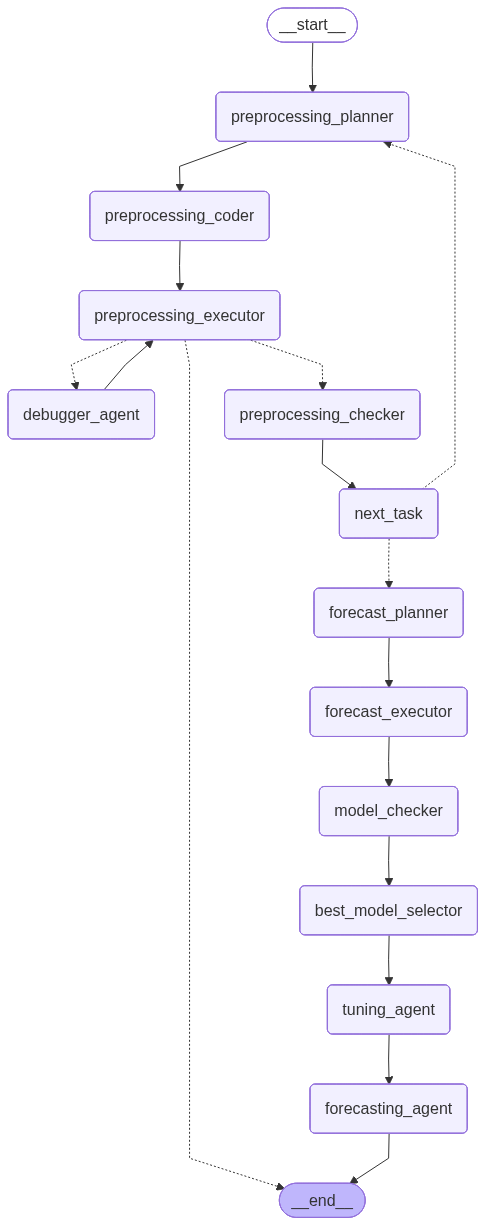

In [12]:
# =========================================================
# COMPILE GRAPH
# =========================================================

graph = builder.compile()


# =========================================================
# VISUALIZE GRAPH
# =========================================================

from IPython.display import (
    Image,
    display
)

graph_png = graph.get_graph().draw_mermaid_png()

display(Image(graph_png))

#print(
 #   graph.get_graph().draw_ascii()
#)


Graph image saved successfully!


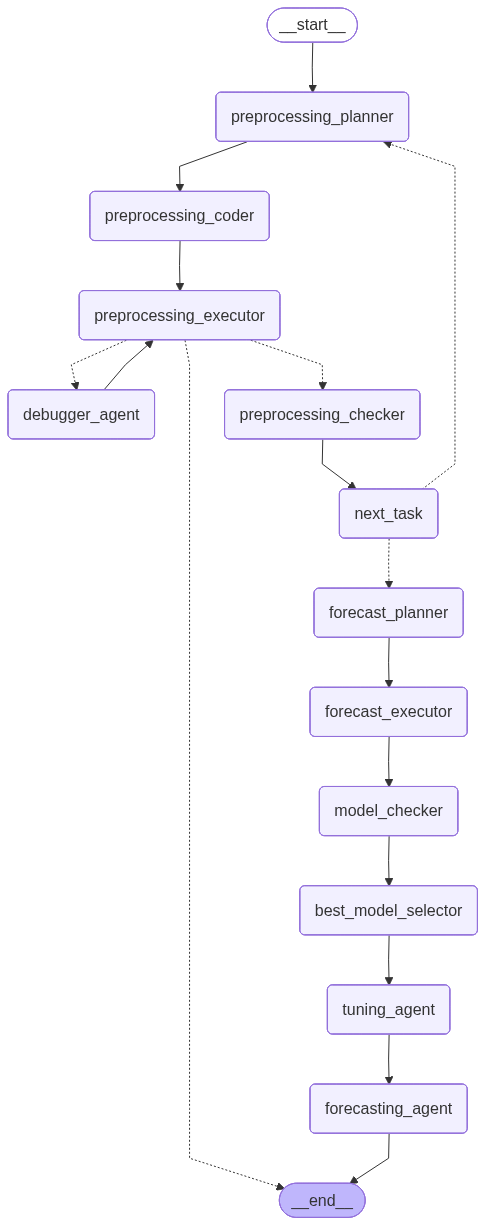

In [13]:
# Save image
with open("langgraph.png", "wb") as f:
    f.write(graph_png)

print("Graph image saved successfully!")

# Display image
display(Image(graph_png))

In [14]:


# =========================================================
# RUN GRAPH
# =========================================================

final_state = graph.invoke({

    "df": df,

    "tasks": PREPROCESSING_TASKS,

    "task_index": 0,

    "current_task": "",

    "generated_code": "",

    "preprocessing_output": "",

    "preprocessing_error": None,

    "retry_count": 0,

    "max_retries": 3,

    "debug_history": [],

    "last_error": "",

    "models": [],

    "results": [],

    "best_model": "",

    "tuning_method": "",

    "best_params": {},

    "forecast_df": None

},
config={
    "recursion_limit": 100
})


# =========================================================
# SAVE PREPROCESSED DATA
# =========================================================

final_state["df"].to_csv(

    PREPROCESSED_DATASET,

    index=False
)


# =========================================================
# SAVE FORECAST
# =========================================================

final_state["forecast_df"].to_csv(

    "Forecast_Output.csv",

    index=False
)


# =========================================================
# COMPLETION
# =========================================================

console.print(

    "\n[bold green]"
    "AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED"
    "[/bold green]"
)

PREPROCESSING TASK 1

Display dataset summary

2026-05-26 19:21:26,453 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated Code

import pandas as pd                                                                                                
import numpy as np                                                                                                 
                                                                                                                   
# Display the summary of the dataset                                                                               
summary = {                                                                                                        
    'Shape': df.shape,                                                                                             
    'Data Types': df.dtypes,                                                                                       
    'Missing Values': df.isnull().sum(),                                                                           
    'Descriptive Statistics': df.describe(include='all')                                                           
}                                                                                                                  
                                                                                                                   
# Print the summary                                                                                                
for key, value in summary.items():                                                                                 
    print(f"{key}:\n{value}\n")                                                                                    

...

            Model Results             
╔═════════╤════════╤════════╤════════╗
║ Model   │ MAE    │ RMSE   │ MAPE   ║
╟─────────┼────────┼────────┼────────╢
║ ARIMA   │ 4.456  │ 4.598  │ nan    ║
║ SARIMAX │ 4.456  │ 4.598  │ nan    ║
║ Prophet │ 33.921 │ 55.755 │ 47.676 ║
╚═════════╧════════╧════════╧════════╝

Best Model → ARIMA

Best Tuning Method → GridSearch

╭──────────────────────────────────────────────── Forecast Output ────────────────────────────────────────────────╮
│          Date   Forecast                                                                                        │
│ 14 2024-01-31  73.186762                                                                                        │
│ 15 2024-02-01  73.534059                                                                                        │
│ 16 2024-02-02  73.385744                                                                                        │
│ 17 2024-02-03  73.449083                                                                                        │
│ 18 2024-02-04  73.422034                                                                                        │
│ 19 2024-02-05  73.433585                                                                                        │
│ 20 2024-02-06  73.428652                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED

In [15]:
#!pip install grandalf